In [14]:
!pip install mne kaggle numpy pandas matplotlib scikit-learn

In [15]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"kanandi","key":"3205ee337793a87a14a30fbb5e758632"}'}

In [16]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [17]:
from mne.datasets.sleep_physionet.age import fetch_data

files = fetch_data(subjects=[0], recording=[1])
print(files)

Using default location ~/mne_data for PHYSIONET_SLEEP...
Creating /root/mne_data


  0%|                                              | 0.00/48.3M [00:00<?, ?B/s]

  0%|                                              | 0.00/4.62k [00:00<?, ?B/s]

Download complete in 07m16s (46.1 MB)
[['/root/mne_data/physionet-sleep-data/SC4001E0-PSG.edf', '/root/mne_data/physionet-sleep-data/SC4001EC-Hypnogram.edf']]


In [18]:
import mne

psg_file, hypnogram_file = files[0]

raw = mne.io.read_raw_edf(psg_file, preload=True)
annotations = mne.read_annotations(hypnogram_file)

raw.set_annotations(annotations)

print(raw)

Extracting EDF parameters from /root/mne_data/physionet-sleep-data/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


/tmp/ipykernel_43325/3416206246.py:5: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_43325/3416206246.py:5: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_43325/3416206246.py:5: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_file, preload=True)


Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...
<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>


/tmp/ipykernel_43325/3416206246.py:8: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


In [19]:
raw_eeg = raw.copy().pick_channels(['EEG Fpz-Cz', 'EEG Pz-Oz'])

print(raw_eeg)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
<RawEDF | SC4001E0-PSG.edf, 2 x 7950000 (79500.0 s), ~121.3 MiB, data loaded>


Using matplotlib as 2D backend.


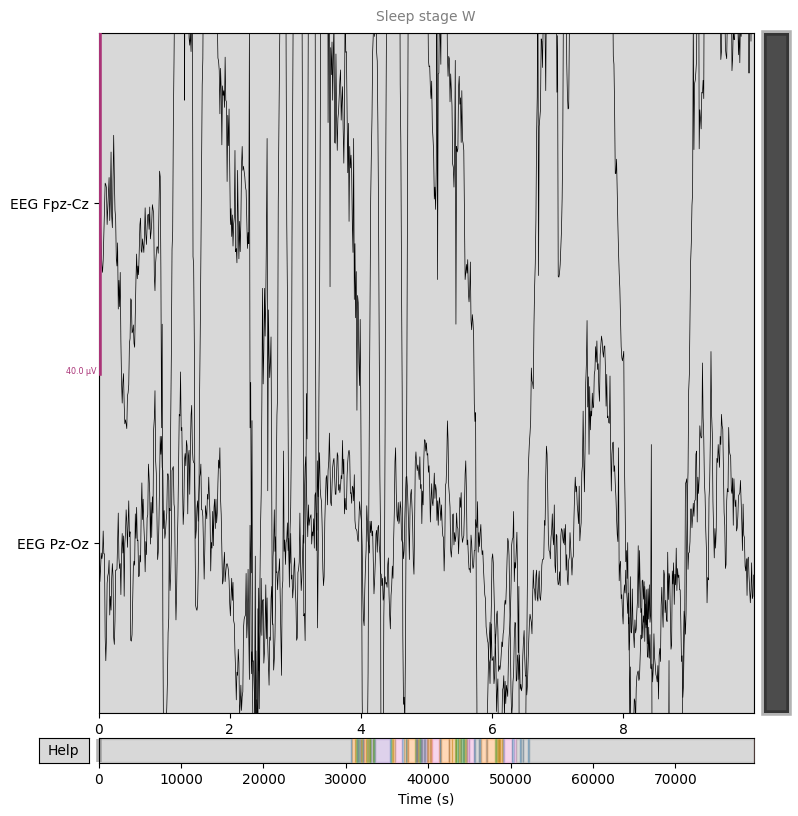

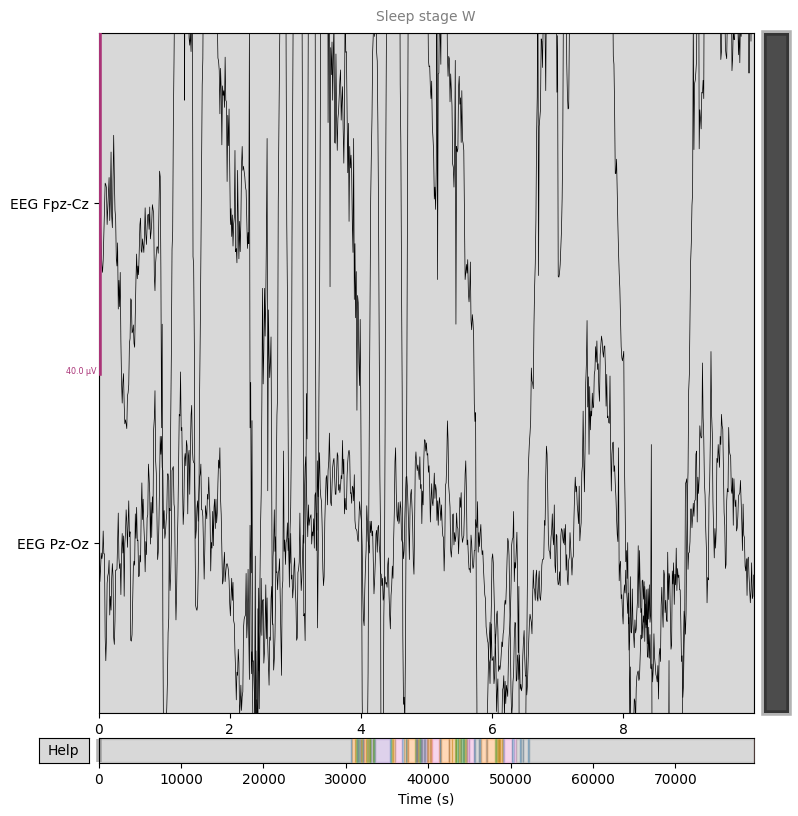

In [20]:
raw_eeg.plot(duration=10, n_channels=2)

In [21]:
events, event_id = mne.events_from_annotations(raw_eeg)

epochs = mne.Epochs(
    raw_eeg,
    events,
    event_id,
    tmin=0,
    tmax=30,
    baseline=None
)

print(epochs)

Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage ?'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Not setting metadata
154 matching events found
No baseline correction applied
0 projection items activated
<Epochs | 154 events (good & bad), 0 – 30 s (baseline off), ~6 KiB, data not loaded,
 np.str_('Sleep stage 1'): 24
 np.str_('Sleep stage 2'): 40
 np.str_('Sleep stage 3'): 48
 np.str_('Sleep stage 4'): 23
 np.str_('Sleep stage ?'): 1
 np.str_('Sleep stage R'): 6
 np.str_('Sleep stage W'): 12>


In [22]:
X = epochs.get_data()
y = epochs.events[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Using data from preloaded Raw for 154 events and 3001 original time points ...
1 bad epochs dropped
X shape: (153, 2, 3001)
y shape: (153,)


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Flatten X (very important)
X_flat = X.reshape(X.shape[0], -1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.41935483870967744


In [24]:
import numpy as np
from scipy.signal import welch

def extract_features(X):
    features = []

    for epoch in X:
        epoch_features = []

        for channel in epoch:
            freqs, psd = welch(channel, fs=100)

            # Frequency bands
            delta = np.mean(psd[(freqs >= 0.5) & (freqs < 4)])
            theta = np.mean(psd[(freqs >= 4) & (freqs < 8)])
            alpha = np.mean(psd[(freqs >= 8) & (freqs < 13)])
            beta  = np.mean(psd[(freqs >= 13) & (freqs < 30)])

            epoch_features.extend([delta, theta, alpha, beta])

        features.append(epoch_features)

    return np.array(features)

X_features = extract_features(X)
print("New shape:", X_features.shape)

New shape: (153, 8)


In [25]:
!git clone https://github.com/anandi404/AI-EEG-SLEEP-ANALYSIS.git

Cloning into 'AI-EEG-SLEEP-ANALYSIS'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 11 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 7.36 KiB | 1.84 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [26]:
%cd AI-EEG-SLEEP-ANALYSIS

/content/AI-EEG-SLEEP-ANALYSIS


In [27]:
!cp /content/*.ipynb /content/AI-EEG-SLEEP-ANALYSIS/

cp: cannot stat '/content/*.ipynb': No such file or directory
